In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
df = pd.read_csv("diabetes.txt", sep = "\t")
df.shape

(768, 9)

In [28]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [29]:
X_true = df[df['Outcome'] == 1]
X_true_f = X_true.drop(columns=['Outcome'])
y_true = X_true['Outcome']
print(X_true_f.shape)
print(y_true.shape)

(268, 8)
(268,)


In [30]:
X_false = df[df['Outcome'] == 0]
X_false_f = X_false.drop(columns=['Outcome'])
y_false = X_false['Outcome']
print(X_false_f.shape)
print(y_false.shape)

(500, 8)
(500,)


# PCA (X_true)

## $\mu$

In [31]:
mu = X_true_f.mean(axis=0)
print(mu)

Pregnancies                   4.865672
Glucose                     141.257463
BloodPressure                70.824627
SkinThickness                22.164179
Insulin                     100.335821
BMI                          35.142537
DiabetesPedigreeFunction      0.550500
Age                          37.067164
dtype: float64


## $\tilde{X}$

In [32]:
X_tilde = X_true_f - mu

In [33]:
X_tilde = X_tilde / X_true_f.std(axis=0)

## $\Sigma$

In [34]:
X_tilde = X_tilde.to_numpy()
I = X_tilde.shape[0]
cov = (1/I) * np.dot(X_tilde.T, X_tilde)
print(cov.shape)

(8, 8)


## Eigen Vector and Eigen Values

In [35]:
eigen_values, eigen_vectors = np.linalg.eig(cov)
print("Eigen value : ", eigen_values)
print("Eigen vectors : ",eigen_vectors)

Eigen value :  [1.9  1.6  0.4  0.5  1.1  0.71 0.93 0.84]
Eigen vectors :  [[-0.29  0.49 -0.14  0.52 -0.21  0.53 -0.23  0.  ]
 [ 0.19  0.22  0.21  0.25  0.67  0.09  0.26  0.53]
 [ 0.16  0.48 -0.19  0.25 -0.32 -0.61  0.41  0.  ]
 [ 0.56  0.18  0.69  0.11 -0.16  0.09 -0.16 -0.33]
 [ 0.44  0.25 -0.56 -0.13  0.43  0.06 -0.23 -0.42]
 [ 0.41 -0.08 -0.22 -0.24 -0.35  0.55  0.51  0.19]
 [ 0.34 -0.   -0.15 -0.06 -0.26 -0.16 -0.61  0.62]
 [-0.24  0.61  0.19 -0.72  0.    0.03 -0.03  0.1 ]]


In [36]:
somme = eigen_values.sum()
pourcentages = np.zeros(8)
for i in range(len(eigen_values)):
    pourcentages[i] = eigen_values[i] / somme
np.set_printoptions(precision=2, suppress=True)
print(pourcentages*100) 

[23.79 20.1   5.01  6.27 13.82  8.88 11.63 10.5 ]


In [37]:
first_pc_weights = eigen_vectors[:, 0]

loadings = pd.DataFrame({
    'Feature': X_true_f.columns,
    'Poids': first_pc_weights
})

print(loadings.sort_values(by='Poids', ascending=False))

                    Feature     Poids
3             SkinThickness  0.564533
4                   Insulin  0.437807
5                       BMI  0.409872
6  DiabetesPedigreeFunction  0.340372
1                   Glucose  0.186633
2             BloodPressure  0.160306
7                       Age -0.242407
0               Pregnancies -0.294089


# PCA (X_false)

In [40]:
mu_false = X_false_f.mean(axis=0)
X_tilde_false = X_false_f - mu_false
X_tilde_false = X_tilde_false / X_false_f.std(axis=0)
X_tilde_false = X_tilde_false.to_numpy()
I_false = X_tilde_false.shape[0]
cov_false = (1/I_false) * np.dot(X_tilde_false.T, X_tilde_false)
eigen_values_false, eigen_vectors_false = np.linalg.eig(cov_false)
somme_false = eigen_values_false.sum()
pourcentages_false = np.zeros(8)
for i in range(len(eigen_values_false)):
    pourcentages_false[i] = eigen_values_false[i] / somme_false

first_pc_weights_false = eigen_vectors_false[:, 0]

loadings_false = pd.DataFrame({
    'Feature': X_false_f.columns,
    'Poids': first_pc_weights_false
})

print(loadings_false.sort_values(by='Poids', ascending=False))

                    Feature     Poids
4                   Insulin  0.497534
3             SkinThickness  0.494598
5                       BMI  0.492730
2             BloodPressure  0.340157
1                   Glucose  0.305955
6  DiabetesPedigreeFunction  0.225002
7                       Age -0.022797
0               Pregnancies -0.067735


# PCA methods with/without normalising

In [42]:
def pca_with_normal(X):
    mu = X.mean(axis=0)
    X_tilde = (X - mu) / X.std(axis=0)
    X_tilde = X_tilde.to_numpy()
    I = X_tilde.shape[0]
    cov = (1/I) * np.dot(X_tilde.T, X_tilde)
    eigen_values, eigen_vectors = np.linalg.eig(cov)
    somme_false = eigen_values_false.sum()
    pourcentages = np.zeros(8)
    for i in range(len(eigen_values)):
        pourcentages[i] = eigen_values[i] / somme

    first_pc_weights = eigen_vectors[:, 0]

    loadings = pd.DataFrame({
        'Feature': X.columns,
        'Poids': first_pc_weights
    })

    print(loadings.sort_values(by='Poids', ascending=False))

In [45]:
def pca_without_normal(X):
    mu = X.mean(axis=0)
    X_tilde = (X - mu)
    X_tilde = X_tilde.to_numpy()
    I = X_tilde.shape[0]
    cov = (1/I) * np.dot(X_tilde.T, X_tilde)
    eigen_values, eigen_vectors = np.linalg.eig(cov)
    somme_false = eigen_values_false.sum()
    pourcentages = np.zeros(8)
    for i in range(len(eigen_values)):
        pourcentages[i] = eigen_values[i] / somme

    first_pc_weights = eigen_vectors[:, 0]

    loadings = pd.DataFrame({
        'Feature': X.columns,
        'Poids': first_pc_weights
    })

    print(loadings.sort_values(by='Poids', ascending=False))

In [44]:
pca_with_normal(X_true_f)

                    Feature     Poids
3             SkinThickness  0.564533
4                   Insulin  0.437807
5                       BMI  0.409872
6  DiabetesPedigreeFunction  0.340372
1                   Glucose  0.186633
2             BloodPressure  0.160306
7                       Age -0.242407
0               Pregnancies -0.294089


In [47]:
pca_with_normal(X_false_f)

                    Feature     Poids
4                   Insulin  0.497534
3             SkinThickness  0.494598
5                       BMI  0.492730
2             BloodPressure  0.340157
1                   Glucose  0.305955
6  DiabetesPedigreeFunction  0.225002
7                       Age -0.022797
0               Pregnancies -0.067735


In [46]:
pca_without_normal(X_true_f)

                    Feature     Poids
0               Pregnancies  0.002125
6  DiabetesPedigreeFunction -0.000276
7                       Age -0.001985
5                       BMI -0.003036
2             BloodPressure -0.014459
3             SkinThickness -0.058634
1                   Glucose -0.062938
4                   Insulin -0.996180


In [48]:
pca_without_normal(X_false_f)

                    Feature     Poids
4                   Insulin  0.992724
1                   Glucose  0.098244
3             SkinThickness  0.062551
5                       BMI  0.020126
2             BloodPressure  0.015086
6  DiabetesPedigreeFunction  0.000684
0               Pregnancies -0.003926
7                       Age -0.016896


# Graphique

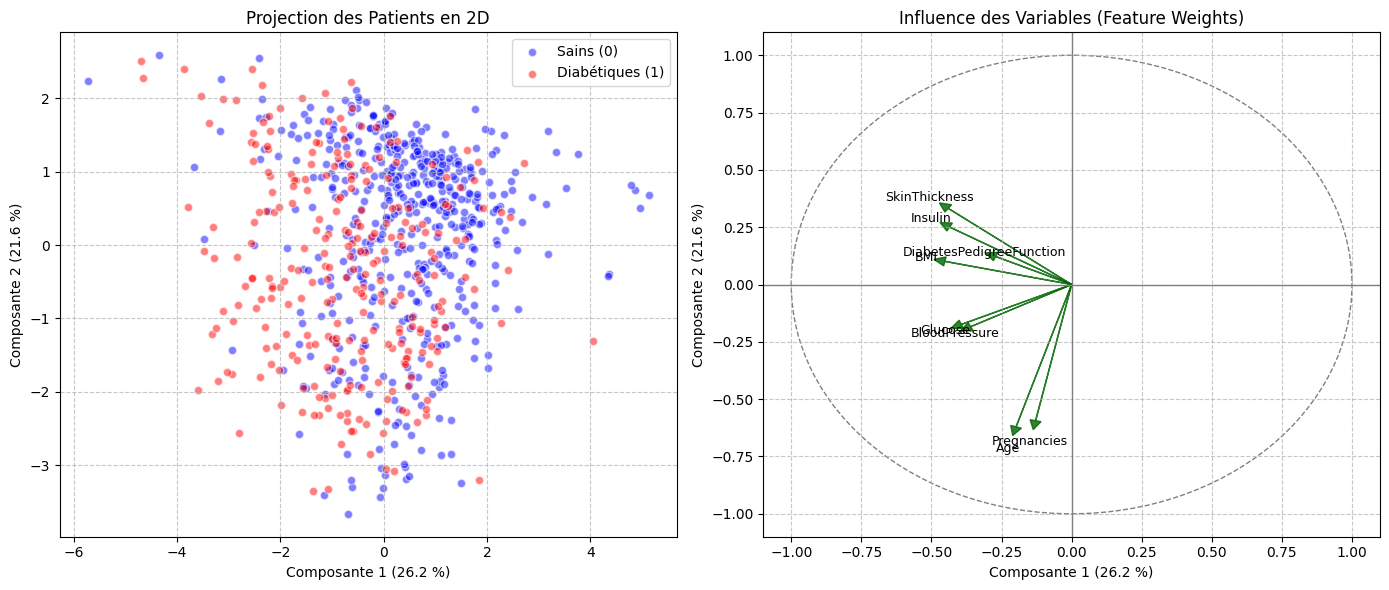

In [49]:
X_all = df.drop(columns=['Outcome'])
y_all = df['Outcome']

# Standardisation de TOUT le tableau
mu_all = X_all.mean(axis=0)
std_all = X_all.std(axis=0)
X_std = (X_all - mu_all) / std_all

# Calcul de la covariance et valeurs/vecteurs propres
X_mat = X_std.to_numpy()
I = X_mat.shape[0]
cov_mat = (1 / (I - 1)) * np.dot(X_mat.T, X_mat) # I-1 est standard ici

eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# IMPORTANT : Trier les valeurs/vecteurs propres du plus grand au plus petit
idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]

# ==========================================
# 2. PROJECTION SUR LES 2 PREMIERS AXES (PC1 et PC2)
# ==========================================
# On garde les 2 premières colonnes (les 2 meilleures directions)
W = eigen_vecs[:, 0:2]

# On projette nos patients : Multiplication matricielle
# X_pca contient maintenant 2 colonnes (Coordonnées X et Y sur le graphique)
X_pca = np.dot(X_mat, W) 

# Pourcentages de variance pour les axes
pc1_var = np.round((eigen_vals[0] / sum(eigen_vals)) * 100, 1)
pc2_var = np.round((eigen_vals[1] / sum(eigen_vals)) * 100, 1)

# ==========================================
# 3. AFFICHAGE GRAPHIQUE (MATPLOTLIB)
# ==========================================
plt.figure(figsize=(14, 6))

# --- GRAPHIQUE 1 : LES PATIENTS ---
plt.subplot(1, 2, 1)

# On dessine les sains (Outcome == 0) en bleu
plt.scatter(X_pca[y_all == 0, 0], X_pca[y_all == 0, 1], 
            c='blue', alpha=0.5, label='Sains (0)', edgecolors='w')

# On dessine les diabétiques (Outcome == 1) en rouge
plt.scatter(X_pca[y_all == 1, 0], X_pca[y_all == 1, 1], 
            c='red', alpha=0.5, label='Diabétiques (1)', edgecolors='w')

plt.xlabel(f"Composante 1 ({pc1_var} %)")
plt.ylabel(f"Composante 2 ({pc2_var} %)")
plt.title("Projection des Patients en 2D")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


# --- GRAPHIQUE 2 : LES VARIABLES (Cercle des corrélations) ---
plt.subplot(1, 2, 2)
features = X_all.columns

for i in range(len(features)):
    # On dessine une flèche pour chaque variable
    plt.arrow(0, 0, W[i, 0], W[i, 1], color='darkgreen', alpha=0.8, 
              head_width=0.04, head_length=0.04)
    # On ajoute le nom de la variable au bout de la flèche
    plt.text(W[i, 0]*1.15, W[i, 1]*1.15, features[i], 
             color='black', ha='center', va='center', fontsize=9)

# Ajout d'un cercle unitaire décoratif pour repère
circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_patch(circle)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel(f"Composante 1 ({pc1_var} %)")
plt.ylabel(f"Composante 2 ({pc2_var} %)")
plt.title("Influence des Variables (Feature Weights)")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

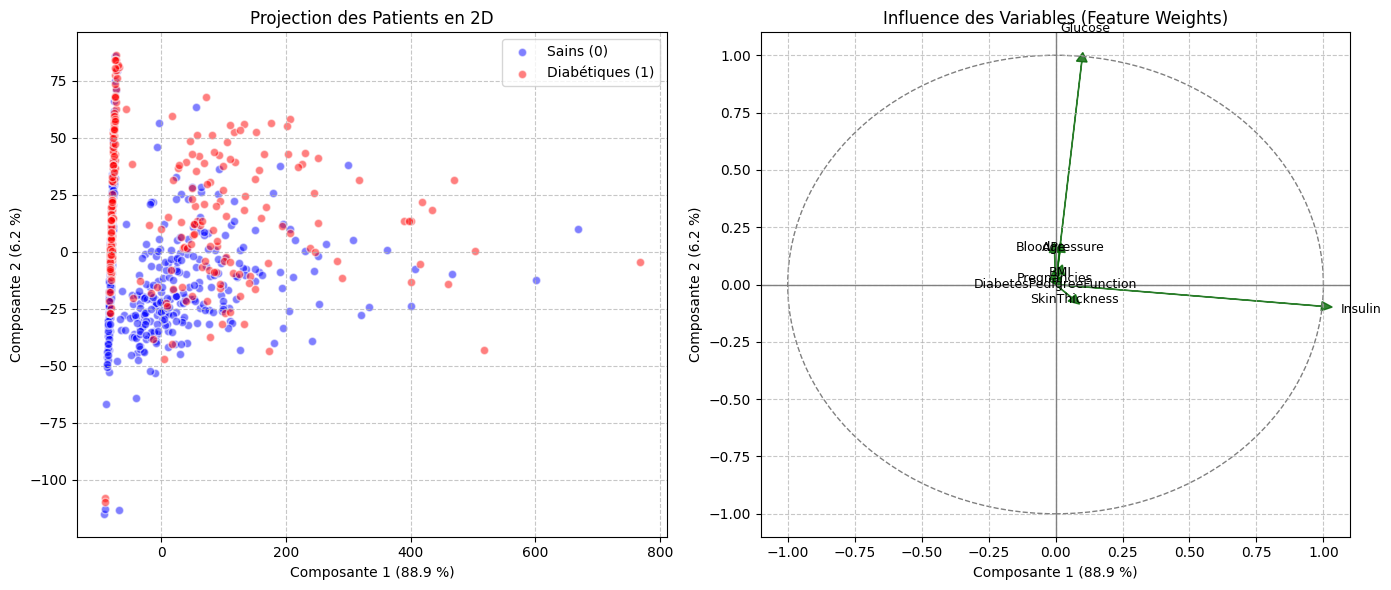

In [50]:
X_all = df.drop(columns=['Outcome'])
y_all = df['Outcome']

# Standardisation de TOUT le tableau
mu_all = X_all.mean(axis=0)
std_all = X_all.std(axis=0)
X_std = (X_all - mu_all)

# Calcul de la covariance et valeurs/vecteurs propres
X_mat = X_std.to_numpy()
I = X_mat.shape[0]
cov_mat = (1 / (I - 1)) * np.dot(X_mat.T, X_mat) # I-1 est standard ici

eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# IMPORTANT : Trier les valeurs/vecteurs propres du plus grand au plus petit
idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]

# ==========================================
# 2. PROJECTION SUR LES 2 PREMIERS AXES (PC1 et PC2)
# ==========================================
# On garde les 2 premières colonnes (les 2 meilleures directions)
W = eigen_vecs[:, 0:2]

# On projette nos patients : Multiplication matricielle
# X_pca contient maintenant 2 colonnes (Coordonnées X et Y sur le graphique)
X_pca = np.dot(X_mat, W) 

# Pourcentages de variance pour les axes
pc1_var = np.round((eigen_vals[0] / sum(eigen_vals)) * 100, 1)
pc2_var = np.round((eigen_vals[1] / sum(eigen_vals)) * 100, 1)

# ==========================================
# 3. AFFICHAGE GRAPHIQUE (MATPLOTLIB)
# ==========================================
plt.figure(figsize=(14, 6))

# --- GRAPHIQUE 1 : LES PATIENTS ---
plt.subplot(1, 2, 1)

# On dessine les sains (Outcome == 0) en bleu
plt.scatter(X_pca[y_all == 0, 0], X_pca[y_all == 0, 1], 
            c='blue', alpha=0.5, label='Sains (0)', edgecolors='w')

# On dessine les diabétiques (Outcome == 1) en rouge
plt.scatter(X_pca[y_all == 1, 0], X_pca[y_all == 1, 1], 
            c='red', alpha=0.5, label='Diabétiques (1)', edgecolors='w')

plt.xlabel(f"Composante 1 ({pc1_var} %)")
plt.ylabel(f"Composante 2 ({pc2_var} %)")
plt.title("Projection des Patients en 2D")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


# --- GRAPHIQUE 2 : LES VARIABLES (Cercle des corrélations) ---
plt.subplot(1, 2, 2)
features = X_all.columns

for i in range(len(features)):
    # On dessine une flèche pour chaque variable
    plt.arrow(0, 0, W[i, 0], W[i, 1], color='darkgreen', alpha=0.8, 
              head_width=0.04, head_length=0.04)
    # On ajoute le nom de la variable au bout de la flèche
    plt.text(W[i, 0]*1.15, W[i, 1]*1.15, features[i], 
             color='black', ha='center', va='center', fontsize=9)

# Ajout d'un cercle unitaire décoratif pour repère
circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_patch(circle)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel(f"Composante 1 ({pc1_var} %)")
plt.ylabel(f"Composante 2 ({pc2_var} %)")
plt.title("Influence des Variables (Feature Weights)")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

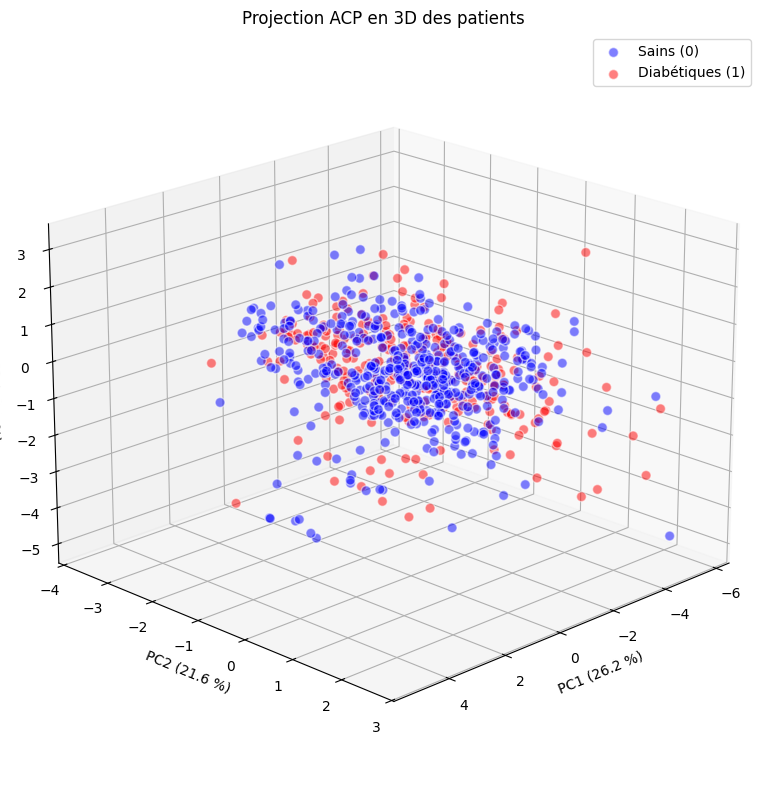

In [53]:
X_all = df.drop(columns=['Outcome'])
y_all = df['Outcome']

mu_all = X_all.mean(axis=0)
std_all = X_all.std(axis=0)
X_std = (X_all - mu_all) / std_all

X_mat = X_std.to_numpy()
I = X_mat.shape[0]
cov_mat = (1 / (I - 1)) * np.dot(X_mat.T, X_mat) 

eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]

# ==========================================
# 2. PROJECTION SUR LES 3 PREMIERS AXES
# ==========================================
# On garde les 3 premières colonnes cette fois-ci !
W_3d = eigen_vecs[:, 0:3]

# Multiplication matricielle : X_pca_3d a maintenant 3 colonnes (X, Y, Z)
X_pca_3d = np.dot(X_mat, W_3d) 

# Pourcentages de variance pour l'affichage
pc1_var = np.round((eigen_vals[0] / sum(eigen_vals)) * 100, 1)
pc2_var = np.round((eigen_vals[1] / sum(eigen_vals)) * 100, 1)
pc3_var = np.round((eigen_vals[2] / sum(eigen_vals)) * 100, 1)

# ==========================================
# 3. AFFICHAGE GRAPHIQUE 3D
# ==========================================
# Création de la figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # C'est ici qu'on active la 3D !

# Coordonnées des patients sains (Outcome == 0)
x_sains = X_pca_3d[y_all == 0, 0]
y_sains = X_pca_3d[y_all == 0, 1]
z_sains = X_pca_3d[y_all == 0, 2]

# Coordonnées des patients diabétiques (Outcome == 1)
x_malades = X_pca_3d[y_all == 1, 0]
y_malades = X_pca_3d[y_all == 1, 1]
z_malades = X_pca_3d[y_all == 1, 2]

# Affichage des deux groupes
ax.scatter(x_sains, y_sains, z_sains, c='blue', alpha=0.5, label='Sains (0)', edgecolors='w', s=50)
ax.scatter(x_malades, y_malades, z_malades, c='red', alpha=0.5, label='Diabétiques (1)', edgecolors='w', s=50)

# Labels et titre
ax.set_xlabel(f'PC1 ({pc1_var} %)')
ax.set_ylabel(f'PC2 ({pc2_var} %)')
ax.set_zlabel(f'PC3 ({pc3_var} %)')
ax.set_title('Projection ACP en 3D des patients')

# Amélioration de l'angle de vue par défaut (élévation, azimut)
# Tu pourras tourner le graphique avec ta souris si tu utilises un notebook interactif
ax.view_init(elev=20, azim=45) 

plt.legend()
plt.tight_layout()
plt.show()